In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import joblib

COLS = ["loan_amnt", "home_ownership", "dti", "annual_inc", "tot_cur_bal",
        "total_rev_hi_lim", "revol_util", "bc_util", "inq_last_6mths",
        "mo_sin_old_rev_tl_op", "num_tl_op_past_12m", "target", "issue_d", "term",
        ]
COLS_TO_STAY = {"target"}

COLS_NN = []
with open("data/columns_grade.json", "r", encoding="utf-8") as f:
    COLS_NN = json.load(f)

In [2]:
df_blank = pd.read_csv("data/lean_dataset.csv", usecols=COLS)
COLS.append("probability")
df_ = pd.read_csv("data/lean_graded.csv", usecols=COLS)
df_['issue_d'] = pd.to_datetime(df_['issue_d'])
df_ = df_[df_['issue_d'] >= '2013-01-01']
df_blank['issue_d'] = pd.to_datetime(df_blank['issue_d'])
df_blank = df_blank[df_blank['issue_d'] >= '2013-01-01']


train_mask = (df_['issue_d'] >= '2013-01-01') & (df_['issue_d'] <= '2015-12-31')
test_mask  = (df_blank['issue_d'] >= '2016-01-01') & (df_blank['issue_d'] <= '2016-12-31')
oot_mask   = (df_blank['issue_d'] >= '2017-01-01') & (df_blank['issue_d'] <= '2017-12-31')

df = df_[train_mask].copy()
df_test  = df_blank[test_mask].copy()
df_oot   = df_blank[oot_mask].copy()

print(f"Rozmiar Train: {len(df)} (Default rate: {df['target'].mean():.2%})")
print(f"Rozmiar Test:  {len(df_test)}  (Default rate: {df_test['target'].mean():.2%})")
print(f"Rozmiar OOT:   {len(df_oot)}   (Default rate: {df_oot['target'].mean():.2%})")

C:\Users\User\AppData\Local\Temp\ipykernel_35832\402417256.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_['issue_d'] = pd.to_datetime(df_['issue_d'])
C:\Users\User\AppData\Local\Temp\ipykernel_35832\402417256.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_blank['issue_d'] = pd.to_datetime(df_blank['issue_d'])


Rozmiar Train: 729275 (Default rate: 18.82%)
Rozmiar Test:  269800  (Default rate: 24.24%)
Rozmiar OOT:   146855   (Default rate: 22.56%)


Statystyki dla ostatnich 24 miesięcy w danych:
        month  total_loans  default_rate  default_percentage
12 2014-01-01        15577      0.158824           15.882391
13 2014-02-01        14934      0.169077           16.907727
14 2014-03-01        15721      0.174480           17.447999
15 2014-04-01        18084      0.183256           18.325592
16 2014-05-01        18027      0.183891           18.389083
17 2014-06-01        16102      0.193703           19.370265
18 2014-07-01        27429      0.188049           18.804915
19 2014-08-01        17660      0.188675           18.867497
20 2014-09-01         9900      0.189192           18.919192
21 2014-10-01        35881      0.197347           19.734679
22 2014-11-01        22833      0.192747           19.274734
23 2014-12-01         9320      0.184657           18.465665
24 2015-01-01        32033      0.200887           20.088659
25 2015-02-01        21558      0.194359           19.435940
26 2015-03-01        22804      0.2086

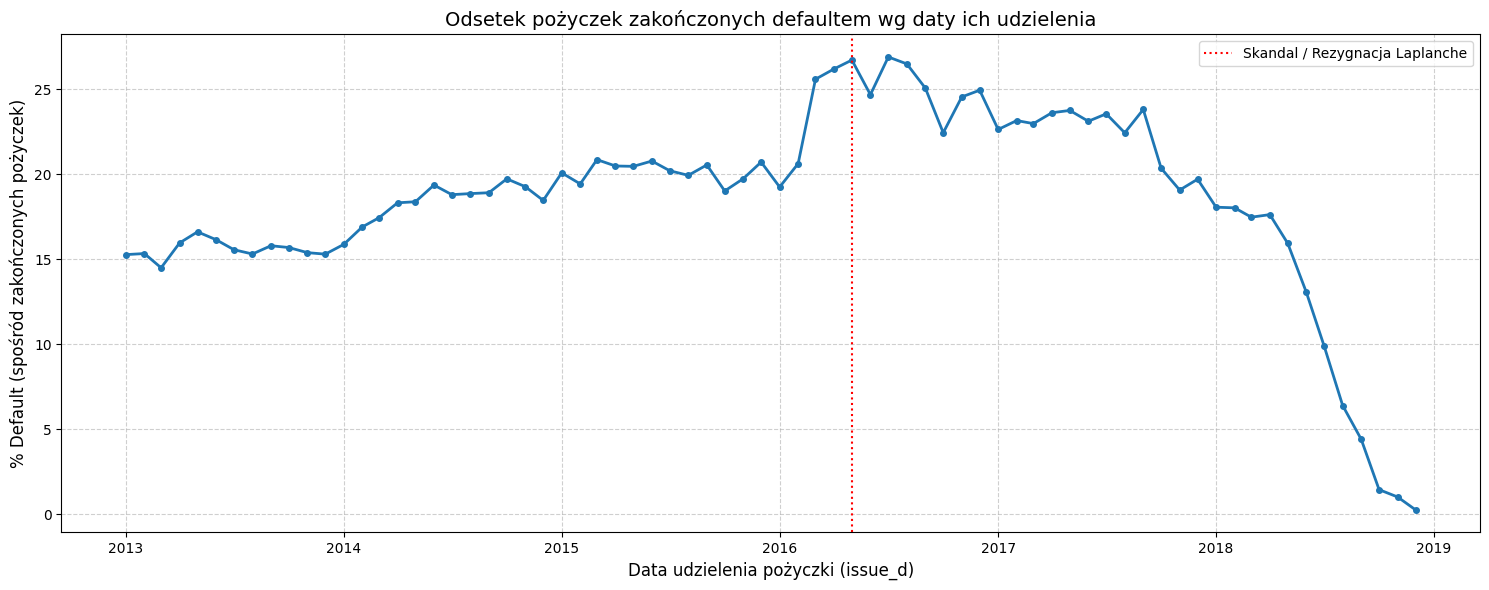

In [3]:
monthly_stats = df_blank.groupby('issue_d')['target'].agg(['count', 'mean']).reset_index()

monthly_stats.columns = ['month', 'total_loans', 'default_rate']
monthly_stats['default_percentage'] = monthly_stats['default_rate'] * 100

print("Statystyki dla ostatnich 24 miesięcy w danych:")
print(monthly_stats.tail(60))

plt.figure(figsize=(15, 6))
plt.plot(monthly_stats['month'], monthly_stats['default_percentage'], 
         marker='o', color='#1f77b4', linewidth=2, markersize=4)

plt.title('Odsetek pożyczek zakończonych defaultem wg daty ich udzielenia', fontsize=14)
plt.xlabel('Data udzielenia pożyczki (issue_d)', fontsize=12)
plt.ylabel('% Default (spośród zakończonych pożyczek)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvline(pd.to_datetime('2016-05-01'), color='red', linestyle=':', label='Skandal / Rezygnacja Laplanche')
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
def calculate_woe(df, feature, target="target"):
    stats = df.groupby(feature)[target].agg(["count", "sum"])
    stats.columns = ["total", "bad"]
    stats["good"] = stats["total"] - stats["bad"]

    perc_bad = (stats['bad'] +0.5) / (stats['bad'].sum())
    perc_good = (stats['good'] +0.5)/ (stats['good'].sum())
    
    stats['WoE'] = np.log(perc_good / perc_bad)
    stats['IV'] = (perc_good - perc_bad) * stats['WoE']

    total_IV = stats["IV"].sum()
    print(f"\n\nIV for {feature} = {total_IV:.4f}\n\n")
    
    return stats.sort_values('WoE'), total_IV

In [5]:
def check_num_bins(df: pd.DataFrame, col: str, target_col: str = "target", start: int = 2, end: int = 10) -> int:
    is_numeric = pd.api.types.is_numeric_dtype(df[col])
    
    if not is_numeric:
        print(f"Analiza zmiennej nienumerycznej: {col}")
        temp_df = df[[col, target_col]].copy()
        temp_df[col] = temp_df[col].fillna("MISSING").astype(str)
        
        result = calculate_woe(temp_df, col)
        print(result[0])

    else:
        best_IV = 0
        print(f"Analiza zmiennej numerycznej: {col}")

        for bin_num in range(start, end):
            temp_df = df[[col, target_col]].copy()
            
            try:
                temp_df[f'{col}_bins'] = pd.qcut(
                    temp_df[col], 
                    q=bin_num, 
                    duplicates='drop'
                ).astype(str)
                actual_bins = temp_df[f'{col}_bins'].nunique()
                
                print(f"\n_____________ Liczba żądanych binów: {bin_num} (Faktycznie: {actual_bins}) _____________")
                
                result = calculate_woe(temp_df, f"{col}_bins")
                
                if result[1] > best_IV:
                    print(result[0])
                    best_IV = result[1]
                
                if actual_bins < bin_num:
                    print(f"Osiągnięto maksymalny podział dla wartości unikalnych przy {actual_bins} binach.")
                    break
                    
            except ValueError as e:
                print(f"Błąd przy {bin_num} binach: {e}")
                continue
        if best_IV < 0.02:
            print("Zmienna o za niskiej wartości informacyjnej.")

    return result

In [6]:
for column in COLS:
    if column in ["target", "issue_d"]:
        continue

    check_num_bins(df, column)

Analiza zmiennej numerycznej: loan_amnt

_____________ Liczba żądanych binów: 2 (Faktycznie: 2) _____________


IV for loan_amnt_bins = 0.0228


                     total    bad    good       WoE        IV
loan_amnt_bins                                               
(12600.0, 35000.0]  363845  76870  286975 -0.144416  0.010876
(999.999, 12600.0]  365430  60386  305044  0.158001  0.011898

_____________ Liczba żądanych binów: 3 (Faktycznie: 3) _____________


IV for loan_amnt_bins = 0.0340


                     total    bad    good       WoE        IV
loan_amnt_bins                                               
(17000.0, 35000.0]  242188  52056  190132 -0.166299  0.009663
(10000.0, 17000.0]  203092  41508  161584 -0.102561  0.003023
(999.999, 10000.0]  283995  43692  240303  0.243035  0.021284

_____________ Liczba żądanych binów: 4 (Faktycznie: 4) _____________


IV for loan_amnt_bins = 0.0318



_____________ Liczba żądanych binów: 5 (Faktycznie: 5) _____________


IV for loan_amn

In [7]:
def create_bins(col: str, num: int = 1, df: pd.DataFrame = df, check=False) -> None:
    global COLS_TO_STAY
    is_numeric = pd.api.types.is_numeric_dtype(df[col])
    
    if not is_numeric:
        print("Już jest kategoryczna.")
        df[f"{col}_bins"] = df[col].astype("category")
        COLS_TO_STAY.add(col)
        return None

    else:
        res, boundries = pd.qcut(
            df[col], 
            q=num, 
            duplicates='drop',
            retbins=True
        )
        df[f'{col}_bins'] = res.astype(str)
        print(calculate_woe(df, f"{col}_bins"))
        if not check:
            COLS_TO_STAY.add(f"{col}_bins")
    
        return boundries

In [8]:
print(f"bc_util median: {df["bc_util"].median()}")
print(f"revol_util median: {df["revol_util"].median()}")

bc_util median: 67.4
revol_util median: 55.4


In [9]:
def check_bc_util(org_df, fill):
    temp_df = org_df[["bc_util", "target"]].copy()
    temp_df["bc_util"] = temp_df["bc_util"].fillna(fill)

    check_num_bins(temp_df, "bc_util")


In [10]:
check_bc_util(df, df["bc_util"].median())

Analiza zmiennej numerycznej: bc_util

_____________ Liczba żądanych binów: 2 (Faktycznie: 2) _____________


IV for bc_util_bins = 0.0168


                 total    bad    good       WoE        IV
bc_util_bins                                             
(67.4, 339.6]   360799  75120  285679 -0.125914  0.008153
(-0.001, 67.4]  368476  62136  306340  0.133673  0.008655

_____________ Liczba żądanych binów: 3 (Faktycznie: 3) _____________


IV for bc_util_bins = 0.0222


                 total    bad    good       WoE        IV
bc_util_bins                                             
(80.6, 339.6]   242672  52310  190362 -0.169958  0.010124
(52.6, 80.6]    243251  45992  197259 -0.005649  0.000011
(-0.001, 52.6]  243352  38954  204398  0.195986  0.012043

_____________ Liczba żądanych binów: 4 (Faktycznie: 4) _____________


IV for bc_util_bins = 0.0241


                 total    bad    good       WoE        IV
bc_util_bins                                             
(86.8, 339.6]  

In [11]:
check_bc_util(df, 85) # as the closest to WoE and median

Analiza zmiennej numerycznej: bc_util

_____________ Liczba żądanych binów: 2 (Faktycznie: 2) _____________


IV for bc_util_bins = 0.0175


                 total    bad    good       WoE        IV
bc_util_bins                                             
(67.9, 339.6]   364045  75872  288173 -0.127183  0.008396
(-0.001, 67.9]  365230  61384  303846  0.137674  0.009088

_____________ Liczba żądanych binów: 3 (Faktycznie: 3) _____________


IV for bc_util_bins = 0.0223


                 total    bad    good       WoE        IV
bc_util_bins                                             
(81.4, 339.6]   242423  52317  190106 -0.171437  0.010295
(52.6, 81.4]    243500  45985  197515 -0.004200  0.000006
(-0.001, 52.6]  243352  38954  204398  0.195986  0.012043

_____________ Liczba żądanych binów: 4 (Faktycznie: 4) _____________


IV for bc_util_bins = 0.0244


                 total    bad    good       WoE        IV
bc_util_bins                                             
(86.8, 339.6]  

In [12]:
df["revol_util"] = df["revol_util"].fillna(df["revol_util"].median()) # WoE Bin near it
check_num_bins(df, "revol_util")

Analiza zmiennej numerycznej: revol_util

_____________ Liczba żądanych binów: 2 (Faktycznie: 2) _____________


IV for revol_util_bins = 0.0119


                  total    bad    good       WoE        IV
revol_util_bins                                           
(55.4, 892.3]    363680  74513  289167 -0.105665  0.005752
(-0.001, 55.4]   365595  62743  302852  0.112500  0.006124

_____________ Liczba żądanych binów: 3 (Faktycznie: 3) _____________


IV for revol_util_bins = 0.0157


                  total    bad    good       WoE        IV
revol_util_bins                                           
(66.8, 892.3]    242212  50572  191640 -0.129478  0.005794
(43.9, 66.8]     243848  47031  196817 -0.030232  0.000308
(-0.001, 43.9]   243215  39653  203562  0.174103  0.009566

_____________ Liczba żądanych binów: 4 (Faktycznie: 4) _____________


IV for revol_util_bins = 0.0169


                  total    bad    good       WoE        IV
revol_util_bins                                    

(                 total    bad   good       WoE        IV
 revol_util_bins                                         
 (85.0, 892.3]    80840  17265  63575 -0.158173  0.002911
 (75.0, 85.0]     80748  16913  63835 -0.133494  0.002056
 (66.8, 75.0]     80624  16394  64230 -0.096159  0.001053
 (59.1, 66.8]     81092  16088  65004 -0.065339  0.000484
 (51.7, 59.1]     81334  15820  65514 -0.040726  0.000187
 (43.9, 51.7]     81422  15123  66299  0.016242  0.000029
 (35.2, 43.9]     80963  14265  66698  0.080647  0.000704
 (24.2, 35.2]     80834  13385  67449  0.155516  0.002552
 (-0.001, 24.2]   81418  12003  69415  0.293221  0.008738,
 np.float64(0.018714101615085483))

In [13]:
def get_iv_trend(df, feature_col, target_col= "target", n_bins=10):
    data = df[[feature_col, target_col, 'issue_d']].copy()
    data['year'] = data['issue_d'].dt.year
    
    data['bins'] = pd.qcut(data[feature_col], q=n_bins, duplicates='drop')
    
    iv_by_year = {}
    years = sorted(data['year'].unique())
    
    for year in years:
        year_data = data[data['year'] == year]
        try:
            _, iv_value = calculate_woe(year_data, 'bins', target_col)
            iv_by_year[year] = iv_value
        except Exception as e:
            print(f"Błąd obliczeń dla roku {year}: {e}")
            iv_by_year[year] = 0
            
    return iv_by_year



IV for bins = 0.0276




IV for bins = 0.0237




IV for bins = 0.0197




C:\Users\User\AppData\Local\Temp\ipykernel_35832\1323708227.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(["count", "sum"])
C:\Users\User\AppData\Local\Temp\ipykernel_35832\1323708227.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(["count", "sum"])
C:\Users\User\AppData\Local\Temp\ipykernel_35832\1323708227.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default 

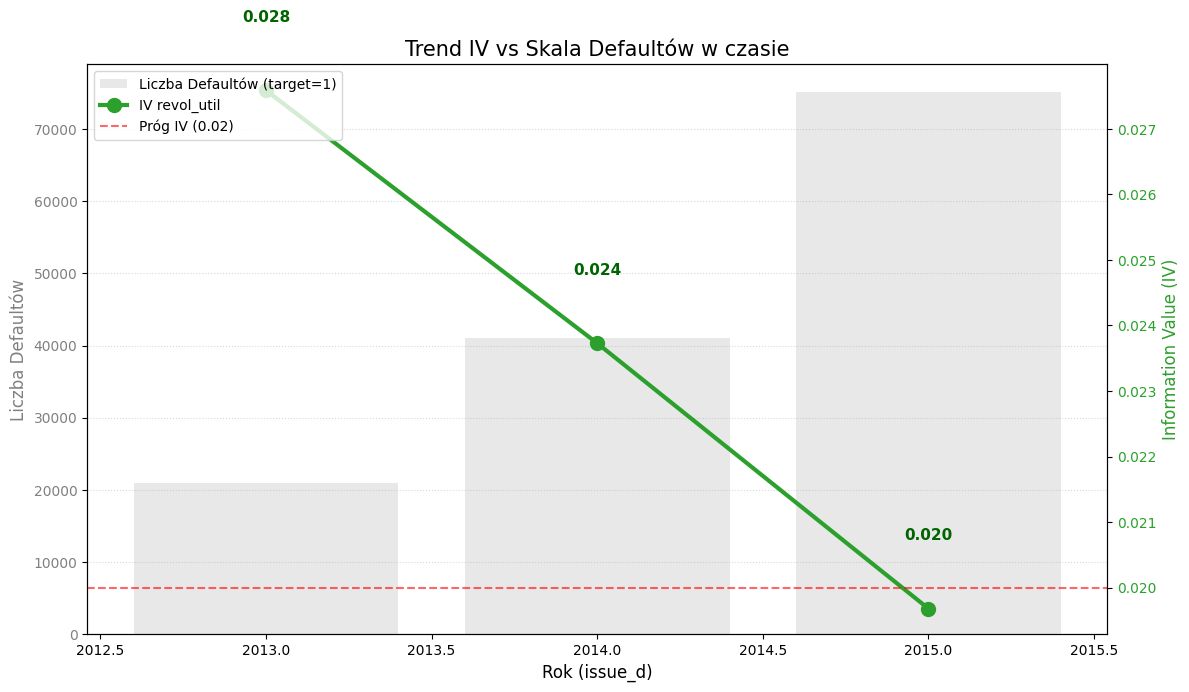

In [14]:
iv_dict = get_iv_trend(df, "revol_util", "target", n_bins=8)

years = sorted(iv_dict.keys())
iv_values = [iv_dict[year] for year in years]

defaults_by_year = df[df['target'] == 1].groupby(df['issue_d'].dt.year).size()
defaults_values = [defaults_by_year.get(year, 0) for year in years]

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.bar(years, defaults_values, color='lightgrey', alpha=0.5, label='Liczba Defaultów (target=1)')
ax1.set_xlabel('Rok (issue_d)', fontsize=12)
ax1.set_ylabel('Liczba Defaultów', fontsize=12, color='grey')
ax1.tick_params(axis='y', labelcolor='grey')

ax2 = ax1.twinx() 
ax2.plot(years, iv_values, marker='o', linestyle='-', color='#2ca02c', linewidth=3, markersize=10, label='IV revol_util')
ax2.axhline(y=0.02, color='red', linestyle='--', alpha=0.6, label='Próg IV (0.02)')

ax2.set_ylabel('Information Value (IV)', fontsize=12, color='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#2ca02c')

for x, y in zip(years, iv_values):
    ax2.text(x, y + 0.001, f'{y:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkgreen')

plt.title('Trend IV vs Skala Defaultów w czasie', fontsize=15)
ax1.grid(True, axis='y', linestyle=':', alpha=0.5)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [15]:
print([int(year) for year in years])

[2013, 2014, 2015]


# PSI

In [16]:
def calculate_psi(df_train, df_oot, col, n_bins=None):
    if col in ["home_ownership", "inq_last_6mths"]:
        col += "_bins"
        train_dist = df_train[col].value_counts(normalize=True)
        oot_dist = df_oot[col].value_counts(normalize=True)
    
    else:
        _, edges = pd.qcut(df_train[col], q=n_bins, retbins=True, duplicates='drop')
        
        t_series = pd.cut(df_train[col], bins=edges, include_lowest=True).astype(str)
        o_series = pd.cut(df_oot[col], bins=edges, include_lowest=True).astype(str)
        
        train_dist = t_series.value_counts(normalize=True)
        oot_dist = o_series.value_counts(normalize=True)


    all_bins = train_dist.index.union(oot_dist.index)
    train_dist = train_dist.reindex(all_bins, fill_value=0.0001).apply(lambda x: x if x > 0 else 0.0001)
    oot_dist = oot_dist.reindex(all_bins, fill_value=0.0001).apply(lambda x: x if x > 0 else 0.0001)

    psi_val = ((oot_dist - train_dist) * np.log(oot_dist / train_dist)).sum()
    return psi_val

In [17]:
bins = [-0.001, 0.001, 1, 3, np.inf]
labels = ['0', '1', '2-3', '3+']

df['inq_last_6mths_bins'] = pd.cut(df['inq_last_6mths'], bins=bins, labels=labels)

calculate_woe(df, "inq_last_6mths_bins")
COLS_TO_STAY.add("inq_last_6mths_bins")

C:\Users\User\AppData\Local\Temp\ipykernel_35832\1323708227.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(["count", "sum"])




IV for inq_last_6mths_bins = 0.0280




In [18]:
def home_owner(val):
    if val in ["RENT", "MORTGAGE"]:
        return val
    return "OWN_OTHER"

In [19]:
df_bc_median = df["bc_util"].median()
df_revo_median = df["revol_util"].median()

df["bc_util"] = df["bc_util"].fillna(df_bc_median)
df["revol_util"] = df["revol_util"].fillna(df_revo_median)

create_bins("loan_amnt", 5)
create_bins("bc_util", 6)
create_bins("revol_util", 8)
create_bins("mo_sin_old_rev_tl_op", 7)
create_bins("num_tl_op_past_12m", 4)
create_bins("dti", 8)
create_bins("annual_inc", 6)
create_bins("tot_cur_bal", 8)
create_bins("total_rev_hi_lim", 8)
create_bins("probability", 7)




df["home_ownership"] = df["home_ownership"].apply(home_owner)
create_bins("home_ownership")



IV for loan_amnt_bins = 0.0345


(                     total    bad    good       WoE        IV
loan_amnt_bins                                               
(21000.0, 35000.0]  145142  31436  113706 -0.176040  0.006508
(15000.0, 21000.0]  137320  29384  107936 -0.160615  0.005102
(10500.0, 15000.0]  155025  30950  124075 -0.073190  0.001165
(7000.0, 10500.0]   144702  24104  120598  0.148377  0.004168
(999.999, 7000.0]   147086  21382  125704  0.309670  0.017511, np.float64(0.03445370119943193))


IV for bc_util_bins = 0.0258


(                 total    bad    good       WoE        IV
bc_util_bins                                             
(92.3, 339.6]   120698  27663   93035 -0.248824  0.011047
(80.6, 92.3]    121974  24647   97327 -0.088285  0.001340
(67.4, 80.6]    118127  22810   95317 -0.031698  0.000164
(52.6, 67.4]    125124  23182  101942  0.019320  0.000064
(33.8, 52.6]    121737  20478  101259  0.136620  0.002984
(-0.001, 33.8]  121615  18476  103139  0.257892  0.01021

In [20]:
list(df.columns)

['loan_amnt',
 'term',
 'home_ownership',
 'annual_inc',
 'issue_d',
 'dti',
 'inq_last_6mths',
 'revol_util',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'bc_util',
 'mo_sin_old_rev_tl_op',
 'num_tl_op_past_12m',
 'target',
 'probability',
 'inq_last_6mths_bins',
 'loan_amnt_bins',
 'bc_util_bins',
 'revol_util_bins',
 'mo_sin_old_rev_tl_op_bins',
 'num_tl_op_past_12m_bins',
 'dti_bins',
 'annual_inc_bins',
 'tot_cur_bal_bins',
 'total_rev_hi_lim_bins',
 'probability_bins',
 'home_ownership_bins']

In [21]:
with open("data/columns_to_stay.json", "w") as f:
    json.dump(list(COLS_TO_STAY), f)

COLS_TO_STAY

{'annual_inc_bins',
 'bc_util_bins',
 'dti_bins',
 'home_ownership',
 'inq_last_6mths_bins',
 'loan_amnt_bins',
 'mo_sin_old_rev_tl_op_bins',
 'num_tl_op_past_12m_bins',
 'probability_bins',
 'revol_util_bins',
 'target',
 'tot_cur_bal_bins',
 'total_rev_hi_lim_bins'}

In [22]:
bins = [-0.001, 0.001, 1, 3, np.inf]
labels = ['0', '1', '2-3', '3+']

df_oot['inq_last_6mths_bins'] = pd.cut(df_oot['inq_last_6mths'], bins=bins, labels=labels)


df_oot["home_ownership"] = df_oot["home_ownership"].apply(home_owner)
create_bins("home_ownership", df=df_oot)


df_oot["bc_util"] = df_oot["bc_util"].fillna(df_bc_median)
df_oot["revol_util"] = df_oot["revol_util"].fillna(df_revo_median)

list(df_oot.columns)

Już jest kategoryczna.


['loan_amnt',
 'term',
 'home_ownership',
 'annual_inc',
 'issue_d',
 'dti',
 'inq_last_6mths',
 'revol_util',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'bc_util',
 'mo_sin_old_rev_tl_op',
 'num_tl_op_past_12m',
 'target',
 'inq_last_6mths_bins',
 'home_ownership_bins']

In [24]:
bin_map = {"loan_amnt": 5,
            "bc_util": 6,
            "revol_util": 8,
            "mo_sin_old_rev_tl_op": 7,
            "num_tl_op_past_12m": 4,
            "dti": 8,
            "annual_inc": 6,
            "tot_cur_bal": 8,
            "total_rev_hi_lim": 8,
            "probability": 7,
    }
to_consider = []
big_psi_change = []

for col in COLS_TO_STAY:
    col = col.removesuffix("_bins")
    if col in ["target", "probability"]:
        continue
    result = calculate_psi(df, df_oot, col, bin_map.get(col))

    if result < 0.1:
        print(f"PSI dla kolumny {col}: {result:.4f}. Brak istotnej zmiany.")
    elif result < 0.25:
        print(f"PSI dla kolumny {col}: {result:.4f}. Niewielka zmiana.")
        to_consider.append(col)
    else:
        print(f"PSI dla kolumny {col}: {result:.4f}. Znaczna zmiana!")
        big_psi_change.append(col)

PSI dla kolumny total_rev_hi_lim: 0.0155. Brak istotnej zmiany.
PSI dla kolumny home_ownership: 0.0049. Brak istotnej zmiany.
PSI dla kolumny bc_util: 0.1421. Niewielka zmiana.
PSI dla kolumny annual_inc: 0.0147. Brak istotnej zmiany.
PSI dla kolumny dti: 0.0050. Brak istotnej zmiany.
PSI dla kolumny loan_amnt: 0.1467. Niewielka zmiana.
PSI dla kolumny inq_last_6mths: 0.0075. Brak istotnej zmiany.
PSI dla kolumny tot_cur_bal: 0.0050. Brak istotnej zmiany.
PSI dla kolumny mo_sin_old_rev_tl_op: 0.0215. Brak istotnej zmiany.
PSI dla kolumny revol_util: 0.1459. Niewielka zmiana.
PSI dla kolumny num_tl_op_past_12m: 0.0146. Brak istotnej zmiany.


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729275 entries, 0 to 729274
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   loan_amnt                  729275 non-null  int64         
 1   term                       729275 non-null  object        
 2   home_ownership             729275 non-null  object        
 3   annual_inc                 729275 non-null  float64       
 4   issue_d                    729275 non-null  datetime64[ns]
 5   dti                        729275 non-null  float64       
 6   inq_last_6mths             729275 non-null  float64       
 7   revol_util                 729275 non-null  float64       
 8   tot_cur_bal                729275 non-null  float64       
 9   total_rev_hi_lim           729275 non-null  float64       
 10  bc_util                    729275 non-null  float64       
 11  mo_sin_old_rev_tl_op       729275 non-null  float64 

In [26]:
print(f"Kolumny którtym warto się przyjrzeć:")
print(*to_consider, sep="\n")

Kolumny którtym warto się przyjrzeć:
bc_util
loan_amnt
revol_util



ANALIZA DLA ZMIENNEJ: bc_util
Statystyki średnich dla bc_util:
Źródło  Rok   Średnia
   OOT 2017 52.632025
 Train 2013 67.020523
 Train 2014 64.332621
 Train 2015 61.559409

Średnia GLOBALNA (Train): 63.41
Średnia GLOBALNA (OOT):   52.63
Różnica procentowa:       17.00%


C:\Users\User\AppData\Local\Temp\ipykernel_35832\74269337.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_plot, x='year', y=var, ax=ax2, palette='Set2', order=order)


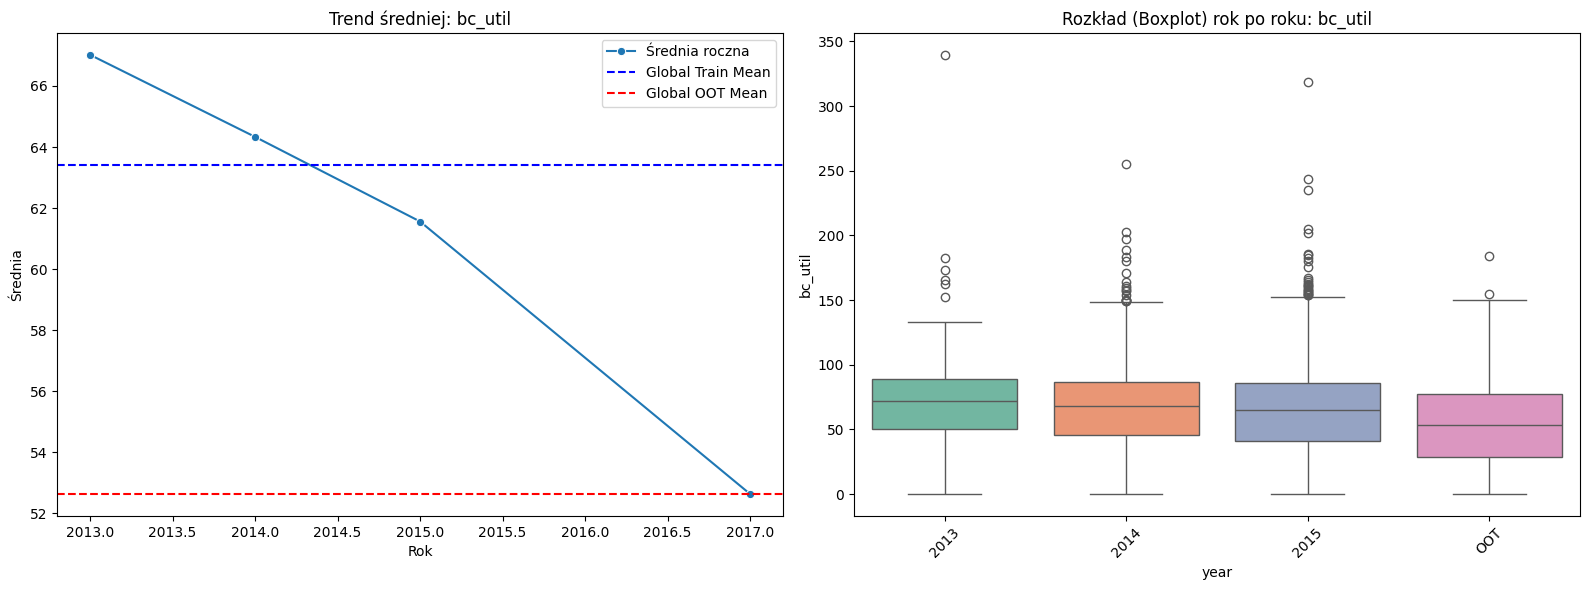

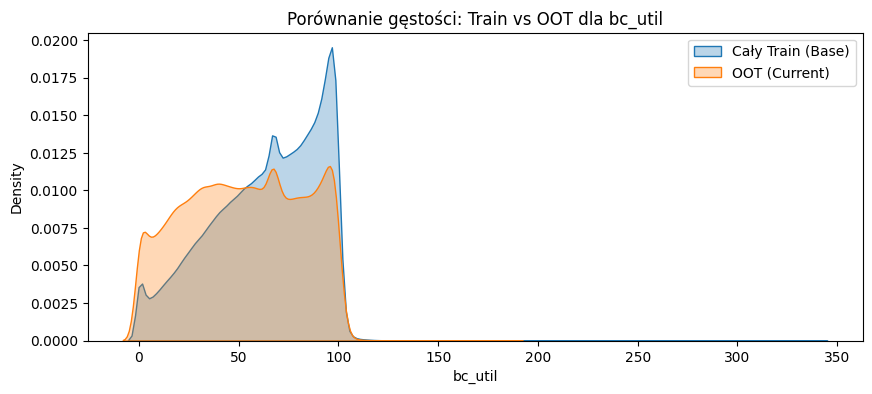


ANALIZA DLA ZMIENNEJ: revol_util
Statystyki średnich dla revol_util:
Źródło  Rok   Średnia
   OOT 2017 45.624794
 Train 2013 58.578832
 Train 2014 55.295602
 Train 2015 53.073941

Średnia GLOBALNA (Train): 54.77
Średnia GLOBALNA (OOT):   45.62
Różnica procentowa:       16.69%


C:\Users\User\AppData\Local\Temp\ipykernel_35832\74269337.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_plot, x='year', y=var, ax=ax2, palette='Set2', order=order)


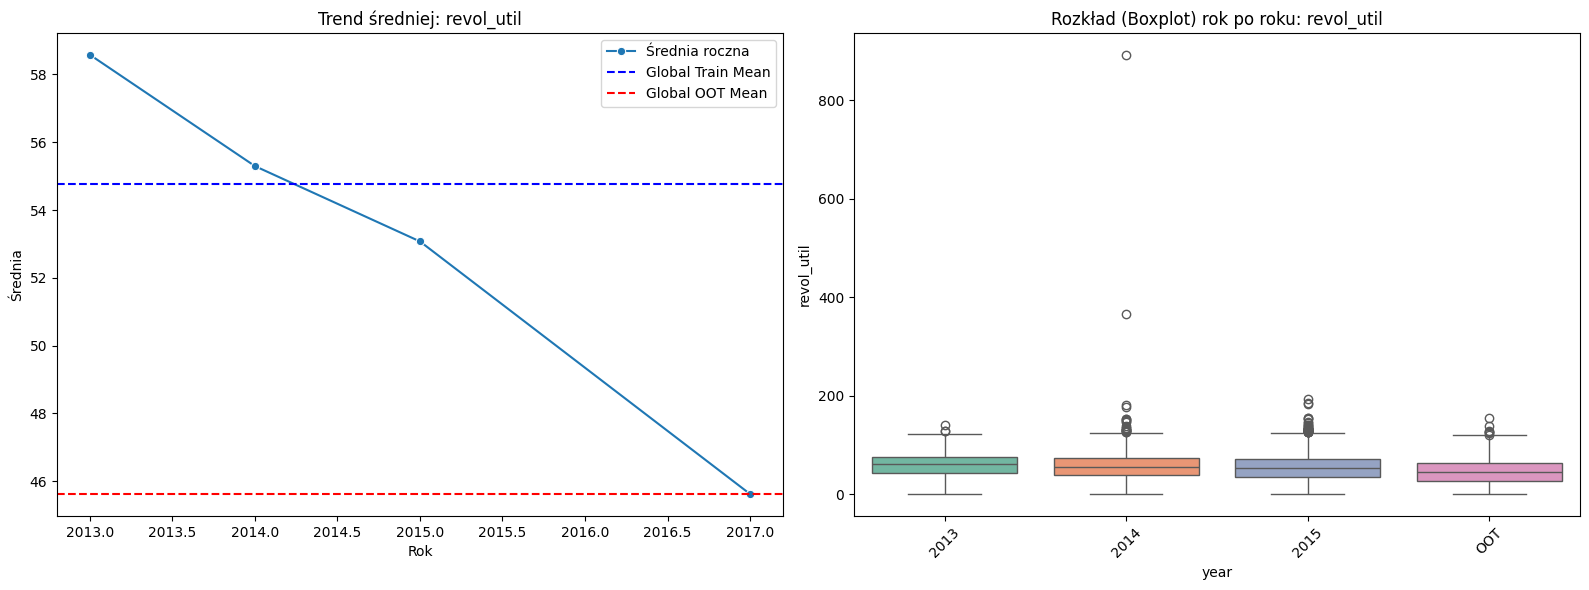

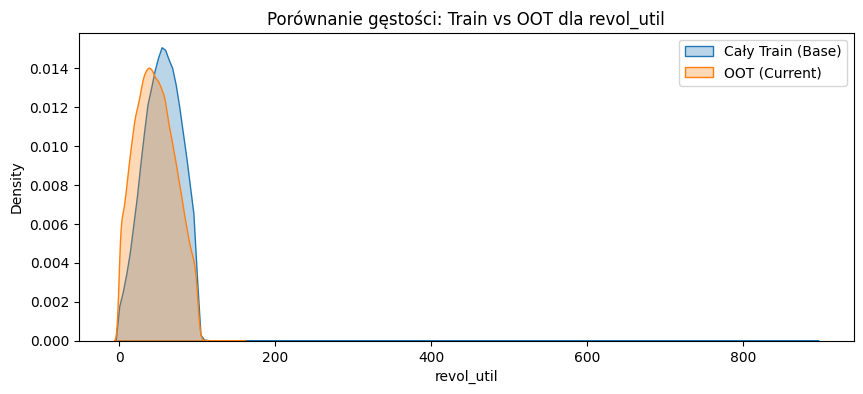


ANALIZA DLA ZMIENNEJ: loan_amnt
Statystyki średnich dla loan_amnt:
Źródło  Rok      Średnia
   OOT 2017 13901.468115
 Train 2013 14706.895573
 Train 2014 14546.814551
 Train 2015 14608.461278

Średnia GLOBALNA (Train): 14607.93
Średnia GLOBALNA (OOT):   13901.47
Różnica procentowa:       4.84%


C:\Users\User\AppData\Local\Temp\ipykernel_35832\74269337.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_plot, x='year', y=var, ax=ax2, palette='Set2', order=order)


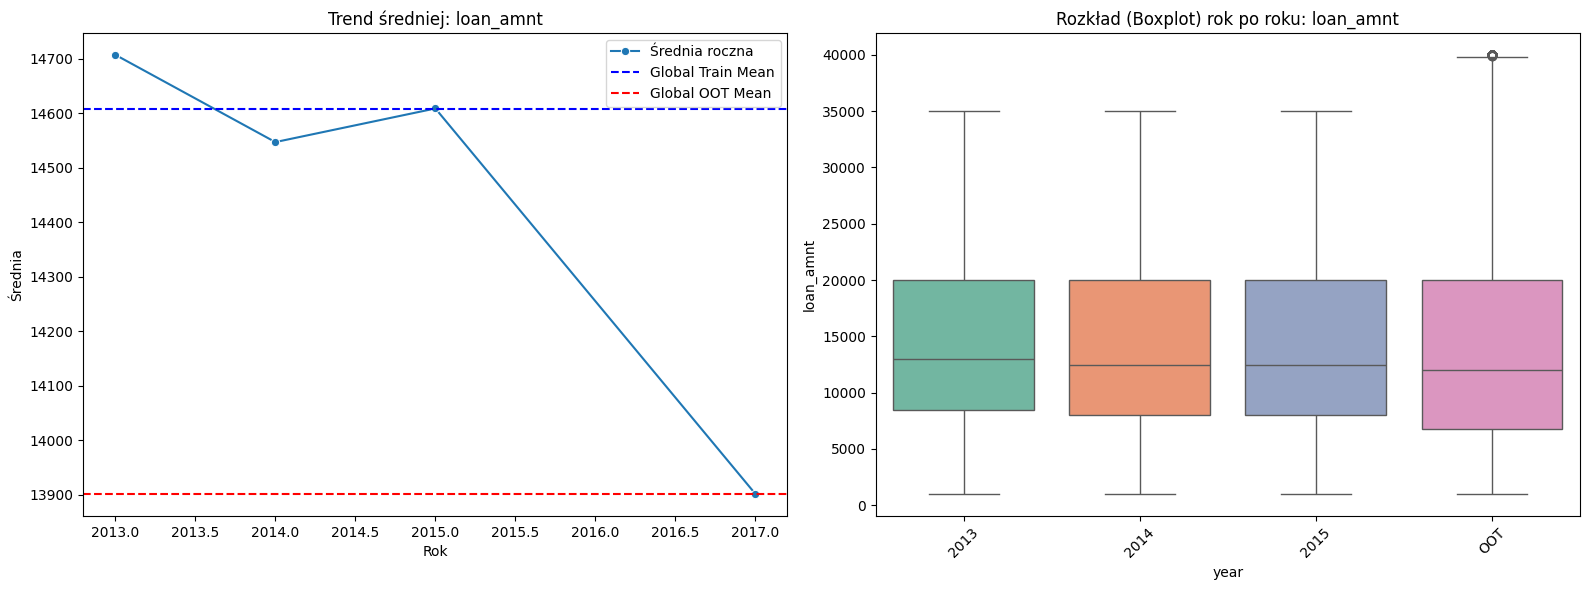

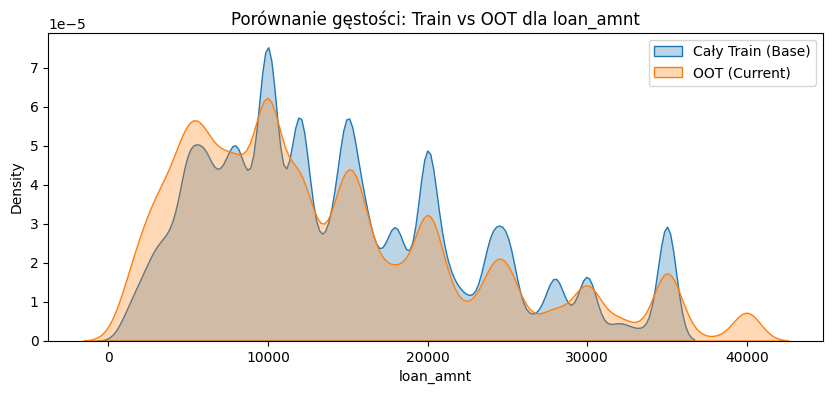

In [ ]:
def prepare_data(data, label):
    d = data.copy()
    if not pd.api.types.is_datetime64_any_dtype(d['issue_d']):
        d['issue_d'] = pd.to_datetime(d['issue_d'])
    d['year'] = d['issue_d'].dt.year
    d['source'] = label
    return d

df_p = prepare_data(df, 'Train')
df_oot_p = prepare_data(df_oot, 'OOT')

full_data = pd.concat([df_p, df_oot_p])
variables = ['bc_util', 'revol_util', 'loan_amnt']

for var in variables:
    print(f"\n{'='*50}")
    print(f"ANALIZA DLA ZMIENNEJ: {var}")
    print(f"{'='*50}")

    stats = full_data.groupby(['source', 'year'])[var].mean().reset_index()
    stats.columns = ['Źródło', 'Rok', 'Średnia']
    
    avg_train = df_p[var].mean()
    avg_oot = df_oot_p[var].mean()

    print(f"Statystyki średnich dla {var}:")
    print(stats.to_string(index=False))
    print(f"\nŚrednia GLOBALNA (Train): {avg_train:.2f}")
    print(f"Średnia GLOBALNA (OOT):   {avg_oot:.2f}")
    print(f"Różnica procentowa:       {abs(avg_train-avg_oot)/avg_train:.2%}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    sns.lineplot(data=stats, x='Rok', y='Średnia', marker='o', ax=ax1, label='Średnia roczna')
    ax1.axhline(avg_train, color='blue', linestyle='--', label='Global Train Mean')
    ax1.axhline(avg_oot, color='red', linestyle='--', label='Global OOT Mean')
    ax1.set_title(f'Trend średniej: {var}')
    ax1.legend()

    order = sorted(df_p['year'].unique()) + ['OOT']
    plot_data = df_p[['year', var]].copy()
    plot_data_oot = df_oot_p[[var]].copy()
    plot_data_oot['year'] = 'OOT'
    combined_plot = pd.concat([plot_data, plot_data_oot])

    sns.boxplot(data=combined_plot, x='year', y=var, ax=ax2, palette='Set2', order=order)
    ax2.set_title(f'Rozkład (Boxplot) rok po roku: {var}')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.kdeplot(df_p[var], label='Cały Train (Base)', fill=True, alpha=0.3)
    sns.kdeplot(df_oot_p[var], label='OOT (Current)', fill=True, alpha=0.3)
    plt.title(f'Porównanie gęstości: Train vs OOT dla {var}')
    plt.xlabel(var)
    plt.legend()
    plt.show()

PODSUMOWANIE LICZBY POŻYCZEK:
 year  yearly_counts dataset
 2013         134793   Train
 2014         221468   Train
 2015         373014   Train
 2017         146855     OOT

Suma całkowita (Train): 729,275
Suma całkowita (OOT):   146,855
RAZEM:                876,130


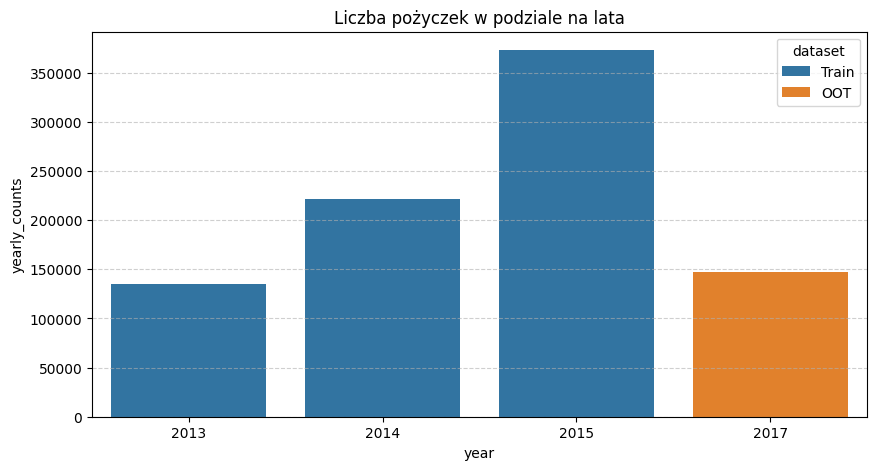

In [28]:
yearly_counts = df_p.groupby('year').size().reset_index(name='yearly_counts')
yearly_counts['dataset'] = 'Train'

oot_count = len(df_oot_p)
oot_year = df_oot_p['year'].unique()
oot_summary = pd.DataFrame({
    'year': oot_year,
    'yearly_counts': [df_oot_p[df_oot_p['year'] == y].shape[0] for y in oot_year],
    'dataset': 'OOT'
})

summary = pd.concat([yearly_counts, oot_summary]).sort_values('year')

print("PODSUMOWANIE LICZBY POŻYCZEK:")
print(summary.to_string(index=False))

total_all = len(df_p) + len(df_oot_p)
print(f"\nSuma całkowita (Train): {len(df_p):,}")
print(f"Suma całkowita (OOT):   {len(df_oot_p):,}")
print(f"RAZEM:                {total_all:,}")

plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x='year', y='yearly_counts', hue='dataset')
plt.title('Liczba pożyczek w podziale na lata')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_35832\2206589773.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yearly_dr, x='year', y='target', palette='magma')


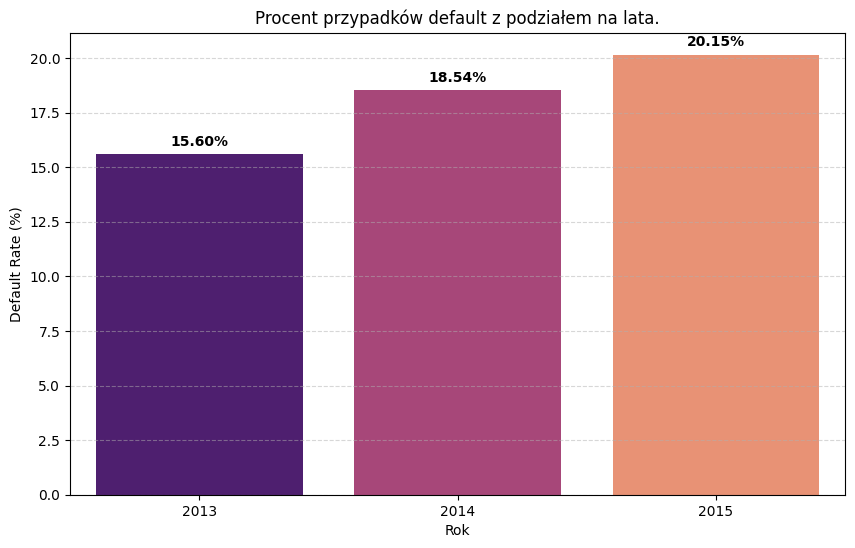

In [29]:
df_['issue_d'] = pd.to_datetime(df_['issue_d'])
df_['year'] = df_['issue_d'].dt.year
yearly_dr = df_.groupby('year')['target'].mean().reset_index()
yearly_dr['target'] = yearly_dr['target'] * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=yearly_dr, x='year', y='target', palette='magma')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.title('Procent przypadków default z podziałem na lata.')
plt.ylabel('Default Rate (%)')
plt.xlabel('Rok')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [30]:
sorted(df_oot.issue_d.dt.month.unique())

[np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6),
 np.int32(7),
 np.int32(8),
 np.int32(9),
 np.int32(10),
 np.int32(11),
 np.int32(12)]

In [31]:
COLS_TO_STAY

{'annual_inc_bins',
 'bc_util_bins',
 'dti_bins',
 'home_ownership',
 'inq_last_6mths_bins',
 'loan_amnt_bins',
 'mo_sin_old_rev_tl_op_bins',
 'num_tl_op_past_12m_bins',
 'probability_bins',
 'revol_util_bins',
 'target',
 'tot_cur_bal_bins',
 'total_rev_hi_lim_bins'}

In [32]:
df.columns

Index(['loan_amnt', 'term', 'home_ownership', 'annual_inc', 'issue_d', 'dti',
       'inq_last_6mths', 'revol_util', 'tot_cur_bal', 'total_rev_hi_lim',
       'bc_util', 'mo_sin_old_rev_tl_op', 'num_tl_op_past_12m', 'target',
       'probability', 'inq_last_6mths_bins', 'loan_amnt_bins', 'bc_util_bins',
       'revol_util_bins', 'mo_sin_old_rev_tl_op_bins',
       'num_tl_op_past_12m_bins', 'dti_bins', 'annual_inc_bins',
       'tot_cur_bal_bins', 'total_rev_hi_lim_bins', 'probability_bins',
       'home_ownership_bins'],
      dtype='object')

# Check troublsome columns

In [33]:
df["tot_cur_bal"]

0         204396.0
1         299890.0
2          34856.0
3          60381.0
4          32365.0
            ...   
729270    294998.0
729271    221830.0
729272    591610.0
729273     73598.0
729274     57477.0
Name: tot_cur_bal, Length: 729275, dtype: float64

In [34]:
bins_cur_check = [-np.inf, 77939.0, 139825.0, 205809.0, 302425.75, np.inf]
labels_cur_check = ["0-77.9k", "77.9k-139.8k", "139.8k-205.8k", "205.8k-302.4k", "302.4k+"]

df["cur_check_bins"] = pd.cut(df["tot_cur_bal"], bins=bins_cur_check, labels=labels_cur_check, include_lowest=True).astype(str)

calculate_woe(df, "cur_check_bins")



IV for cur_check_bins = 0.0314




(                 total    bad    good       WoE        IV
 cur_check_bins                                           
 0-77.9k         364640  76075  288565 -0.128495  0.008588
 77.9k-139.8k     91161  18124   73037 -0.067983  0.000590
 139.8k-205.8k    91156  16220   74936  0.068674  0.000577
 205.8k-302.4k    91158  14434   76724  0.208909  0.005104
 302.4k+          91160  12403   78757  0.386704  0.016498,
 np.float64(0.03135756137160902))

In [35]:
bins = [-0.001, 0.001, 1, 3, np.inf]
labels = ['0', '1', '2-3', '3+']

df_oot['inq_last_6mths_bins'] = pd.cut(df_oot['inq_last_6mths'], bins=bins, labels=labels)


calculate_woe(df, "inq_last_6mths_bins")



IV for inq_last_6mths_bins = 0.0280




C:\Users\User\AppData\Local\Temp\ipykernel_35832\1323708227.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(feature)[target].agg(["count", "sum"])


(                      total    bad    good       WoE        IV
 inq_last_6mths_bins                                           
 3+                    12987   3345    9642 -0.403127  0.003260
 2-3                  104786  24575   80211 -0.278774  0.012144
 1                    199782  40262  159520 -0.084939  0.002029
 0                    411720  69074  342646  0.139823  0.010560,
 np.float64(0.027992313896602044))

In [36]:
check_num_bins(df, "inq_last_6mths")

Analiza zmiennej numerycznej: inq_last_6mths

_____________ Liczba żądanych binów: 2 (Faktycznie: 1) _____________


IV for inq_last_6mths_bins = 0.0000


                      total     bad    good       WoE            IV
inq_last_6mths_bins                                                
(-0.001, 6.0]        729275  137256  592019 -0.000003  7.830244e-12
Osiągnięto maksymalny podział dla wartości unikalnych przy 1 binach.
Zmienna o za niskiej wartości informacyjnej.


(                      total     bad    good       WoE            IV
 inq_last_6mths_bins                                                
 (-0.001, 6.0]        729275  137256  592019 -0.000003  7.830244e-12,
 np.float64(7.830244321766002e-12))

In [37]:
def check_default_rates(df):
    over_300k = df[df['tot_cur_bal'] > 300000]
    dr_300k = over_300k['target'].mean()
    
    over_150k = df[df['tot_cur_bal'] > 150000]
    dr_150k = over_150k['target'].mean()
    
    between_150_300 = df[(df['tot_cur_bal'] > 150000) & (df['tot_cur_bal'] <= 300000)]
    dr_mid = between_150_300['target'].mean()

    print("--- DEFAULT RATES (tot_cur_bal) ---")
    print(f"Default Rate (> 300k):      {dr_300k:.4f} (N: {len(over_300k)})")
    print(f"Default Rate (150k - 300k): {dr_mid:.4f} (N: {len(between_150_300)})")
    print(f"Default Rate (> 150k total):{dr_150k:.4f} (N: {len(over_150k)})")

def check_loan_by_purpose(df_purpose):
    loan_purpose = df_purpose.groupby('purpose')['tot_cur_bal'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    
    print("\n--- LOAN AMOUNT BY PURPOSE ---")
    print(loan_purpose)


def check_loan_stats_by_purpose(df_purpose):
    stats = df_purpose.groupby('purpose')['tot_cur_bal'].agg(['count', 'mean', 'median', 
                                                           lambda x: x.quantile(0.25), 
                                                           lambda x: x.quantile(0.75)])
    
    stats.columns = ['Count', 'Mean', 'Median (Q50)', 'Q25', 'Q75']
    
    stats = stats.sort_values('Median (Q50)', ascending=False)
    
    print("--- TOT_CUR_BAL QUANTILES BY PURPOSE ---")
    print(stats.round(2))


def check_default_rate_step_75k(df):
    max_val = df['tot_cur_bal'].max()
    bins = list(range(0, 450001, 75000)) + [np.inf]
    
    labels = [f"{int(bins[i]/1000)}k-{int(bins[i+1]/1000)}k" if bins[i+1] != np.inf else f"{int(bins[i]/1000)}k+" 
              for i in range(len(bins)-1)]
    
    df['temp_bins'] = pd.cut(df['tot_cur_bal'], bins=bins, labels=labels, include_lowest=True)
    
    dr_stats = df.groupby('temp_bins', observed=True)['target'].agg(['count', 'mean'])
    dr_stats.columns = ['Total_N', 'Default_Rate']
    
    print("\n--- DEFAULT RATE EVERY 75k (tot_cur_bal) ---")
    print(dr_stats.round(4))
    
    df.drop(columns=['temp_bins'], inplace=True)


In [38]:
df_purpose = pd.read_csv("data/lean_dataset.csv", usecols=["purpose", "tot_cur_bal", "issue_d", "target"])
df_purpose["issue_d"] = pd.to_datetime(df_purpose['issue_d'])
df_purpose = df_purpose[df_purpose["issue_d"].dt.year > 2013]

C:\Users\User\AppData\Local\Temp\ipykernel_35832\154905658.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_purpose["issue_d"] = pd.to_datetime(df_purpose['issue_d'])


In [39]:
check_default_rates(df_purpose) 
check_loan_by_purpose(df_purpose)
check_loan_stats_by_purpose(df_purpose)
check_default_rate_step_75k(df_purpose)

--- DEFAULT RATES (tot_cur_bal) ---
Default Rate (> 300k):      0.1525 (N: 141148)
Default Rate (150k - 300k): 0.1794 (N: 235717)
Default Rate (> 150k total):0.1693 (N: 376865)

--- LOAN AMOUNT BY PURPOSE ---
                             mean   count
purpose                                  
educational         357838.000000       1
home_improvement    198220.293308   69381
credit_card         142695.768460  233415
debt_consolidation  138544.701001  613068
small_business      134738.068004   10220
medical             125488.007825   12396
wedding             122685.266667      15
house               122383.965021    5346
renewable_energy    122161.281669     671
major_purchase      119886.594113   22048
other               118625.693494   60759
vacation            112120.636525    7321
car                 111934.279770   10430
moving               93300.753829    7377
--- TOT_CUR_BAL QUANTILES BY PURPOSE ---
                     Count       Mean  Median (Q50)        Q25        Q75
purp

# Model

In [40]:
import torch
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import statsmodels.api as sm
from model_grade import FlexibleScoringNet
from utils import prepare_df

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")


Używane urządzenie: cuda


In [41]:
mapped_bins = {
    "loan_amnt": {
        "bins": [-np.inf, 7000.0, 10500.0, 15000.0, 21000.0, np.inf],
        "labels": ["0-7k", "7k-10.5k", "10.5k-15k", "15k-21k", "21k+"]
    },
    "bc_util": {
        "bins": [-np.inf, 33.8, 52.6, 67.4, 80.6, 92.3, np.inf],
        "labels": ["0-33.8", "33.8-52.6", "52.6-67.4", "67.4-80.6", "80.6-92.3", "92.3+"]
    },
    "revol_util": {
        "bins": [-np.inf, 25.8, 37.5, 46.9, 55.4, 63.8, 72.8, 83.6, np.inf],
        "labels": ["0-25.8", "25.8-37.5", "37.5-46.9", "46.9-55.4", "55.4-63.8", "63.8-72.8", "72.8-83.6", "83.6+"]
    },
    "mo_sin_old_rev_tl_op": {
        "bins": [-np.inf, 96.0, 124.0, 156.0, 216.0, np.inf],
        "labels": ["0-96", "96-124", "124-156", "156-216", "216+"]
    },
    "num_tl_op_past_12m": {
        "bins": [-np.inf, 1.0, 2.0, 3.0, np.inf],
        "labels": ["0-1", "1-2", "2-3", "3+"]
    },
    "dti": {
        "bins": [-np.inf, 8.52, 12.06, 14.97, 17.8, 20.76, 24.2, 28.61, np.inf],
        "labels": ["0-8.5", "8.5-12.1", "12.1-15", "15-17.8", "17.8-20.8", "20.8-24.2", "24.2-28.6", "28.6+"]
    },
    "annual_inc": {
        "bins": [-np.inf, 40000.0, 51000.0, 65000.0, 80000.0, 105000.0, np.inf],
        "labels": ["0-40k", "40k-51k", "51k-65k", "65k-80k", "80k-105k", "105k+"]
    },
    "tot_cur_bal": {
        "bins": [-np.inf, 225000.0, np.inf],
        "labels": ["0-225k", "225+"]
    },
    "total_rev_hi_lim": {
        "bins": [-np.inf, 9200.0, 13700.0, 18200.0, 23300.0, 29900.0, 39232.5, 56000.0, np.inf],
        "labels": ["0-9.2k", "9.2k-13.7k", "13.7k-18.2k", "18.2k-23.3k", "23.3k-29.9k", "29.9k-39.2k", "39.2k-56k", "56k+"]
    },
    "inq_last_6mths": {
        "bins": [-np.inf, 0.001, 1, 3, np.inf],
        "labels": ["0", "1", "2", "3+"]
    },
    "probability": {
        "bins": [-np.inf, 0.341, 0.404, 0.508, 0.540, np.inf],
        "labels": ["0-0.341", "0.341-0.404", "0.404-0.508", "0.508-0.540", "0.540+"]
    }
}

mapped_fills = {
    "revol_util": df_revo_median,
    "bc_util": df_bc_median,
    "total_rev_hi_lim": 0,
    "inq_last_6mths": 0,
    "annual_inc": 0,
    "home_ownership": 0,
    "num_tl_op_past_12m": 0,
    "probability": 0,
    "bc_util": 0,
    "dti": 0,
    "target": 0,
    "loan_amnt": 0,
    "revol_util": 0,
    "tot_cur_bal": 0,
    "mo_sin_old_rev_tl_op": 0,
}

def home_owner(val):
    if val in ["RENT", "MORTGAGE"]:
        return val
    return "OWN_OTHER"


def apply_bins(df, bin_map, mapped_fills):
    df_mapped = df.copy()
    
    df_mapped = df_mapped.fillna(mapped_fills)
    for col, config in bin_map.items():
        if col in df_mapped.columns:
            df_mapped[f"{col}_bins"] = pd.cut(
                df_mapped[col], 
                bins=config['bins'], 
                labels=config['labels'], 
                include_lowest=True
            ).astype(str)
    return df_mapped

In [42]:
data = None
print(1, data)
data = pd.read_csv("data/ready_train_dataset.csv")
print("2__________________________________\n\n\n\n", df.columns)
first = list(data.columns)
data = apply_bins(data, mapped_bins, mapped_fills)
second = list(data.columns)
print(*[col for col in second if col not in first])

data = data[list(COLS_TO_STAY)]

X = data.drop('target', axis=1)
y = data['target']

X_dummies = pd.get_dummies(X, drop_first=True)
print(X_dummies.columns)

X_with_const = sm.add_constant(X_dummies)
logit_model = sm.Logit(y, X_with_const.astype(float))
result = logit_model.fit()

print(result.summary())

lr_model = LogisticRegression(
    penalty='l2', 
    C=1.0, 
    solver='lbfgs', 
    max_iter=1000, 
    class_weight='balanced' 
)

lr_model.fit(X_dummies, y)
y_pred_proba = lr_model.predict_proba(X_dummies)[:, 1]
y_pred = lr_model.predict(X_dummies)

auc_val = roc_auc_score(y, y_pred_proba)
gini_val = 2 * auc_val - 1

print(f"\n Wyniki\n")
print(f"AUC: {auc_val:.4f}")
print(f"Gini: {gini_val:.4f}")

coefficients = pd.DataFrame({
    'Feature': ['Intercept'] + list(X_dummies.columns),
    'Coeff': [lr_model.intercept_[0]] + list(lr_model.coef_[0])
})

print("\n Współczynniki\n")
print(coefficients)

1 None
2__________________________________



 Index(['loan_amnt', 'term', 'home_ownership', 'annual_inc', 'issue_d', 'dti',
       'inq_last_6mths', 'revol_util', 'tot_cur_bal', 'total_rev_hi_lim',
       'bc_util', 'mo_sin_old_rev_tl_op', 'num_tl_op_past_12m', 'target',
       'probability', 'inq_last_6mths_bins', 'loan_amnt_bins', 'bc_util_bins',
       'revol_util_bins', 'mo_sin_old_rev_tl_op_bins',
       'num_tl_op_past_12m_bins', 'dti_bins', 'annual_inc_bins',
       'tot_cur_bal_bins', 'total_rev_hi_lim_bins', 'probability_bins',
       'home_ownership_bins', 'cur_check_bins'],
      dtype='object')
loan_amnt_bins bc_util_bins revol_util_bins mo_sin_old_rev_tl_op_bins num_tl_op_past_12m_bins dti_bins annual_inc_bins tot_cur_bal_bins total_rev_hi_lim_bins inq_last_6mths_bins probability_bins
Index(['total_rev_hi_lim_bins_13.7k-18.2k',
       'total_rev_hi_lim_bins_18.2k-23.3k',
       'total_rev_hi_lim_bins_23.3k-29.9k',
       'total_rev_hi_lim_bins_29.9k-39.2k', 'total_rev_hi_

c:\Uzytkowe\projekty\Risk\risk_pred\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Uzytkowe\projekty\Risk\risk_pred\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
c:\Uzytkowe\projekty\Risk\risk_pred\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: inf
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               729275
Model:                          Logit   Df Residuals:                   729221
Method:                           MLE   Df Model:                           53
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                    -inf
Time:                        14:29:21   Log-Likelihood:                   -inf
converged:                      False   LL-Null:                   -3.5269e+05
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                              1.184e+05        nan        nan        nan         nan         nan
t

c:\Uzytkowe\projekty\Risk\risk_pred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



 Wyniki

AUC: 0.7012
Gini: 0.4025

 Współczynniki

                              Feature     Coeff
0                           Intercept -0.514287
1   total_rev_hi_lim_bins_13.7k-18.2k -0.183948
2   total_rev_hi_lim_bins_18.2k-23.3k -0.228910
3   total_rev_hi_lim_bins_23.3k-29.9k -0.264167
4   total_rev_hi_lim_bins_29.9k-39.2k -0.307266
5     total_rev_hi_lim_bins_39.2k-56k -0.382391
6          total_rev_hi_lim_bins_56k+ -0.508534
7    total_rev_hi_lim_bins_9.2k-13.7k -0.120619
8             home_ownership_MORTGAGE -0.276367
9                  home_ownership_OWN -0.163790
10                home_ownership_RENT -0.071654
11             bc_util_bins_33.8-52.6  0.011243
12             bc_util_bins_52.6-67.4  0.059878
13             bc_util_bins_67.4-80.6  0.077894
14             bc_util_bins_80.6-92.3  0.113384
15                 bc_util_bins_92.3+  0.288731
16              annual_inc_bins_105k+ -0.586466
17            annual_inc_bins_40k-51k -0.206433
18            annual_inc_bins_51k-65

In [44]:
listed_features = [col.removesuffix("_bins") for col in COLS_TO_STAY]
listed_features

['total_rev_hi_lim',
 'target',
 'home_ownership',
 'bc_util',
 'annual_inc',
 'dti',
 'loan_amnt',
 'inq_last_6mths',
 'tot_cur_bal',
 'mo_sin_old_rev_tl_op',
 'revol_util',
 'num_tl_op_past_12m',
 'probability']

Index(['total_rev_hi_lim_bins_13.7k-18.2k',
       'total_rev_hi_lim_bins_18.2k-23.3k',
       'total_rev_hi_lim_bins_23.3k-29.9k',
       'total_rev_hi_lim_bins_29.9k-39.2k', 'total_rev_hi_lim_bins_39.2k-56k',
       'total_rev_hi_lim_bins_56k+', 'total_rev_hi_lim_bins_9.2k-13.7k',
       'home_ownership_OWN_OTHER', 'home_ownership_RENT',
       'bc_util_bins_33.8-52.6', 'bc_util_bins_52.6-67.4',
       'bc_util_bins_67.4-80.6', 'bc_util_bins_80.6-92.3',
       'bc_util_bins_92.3+', 'annual_inc_bins_105k+',
       'annual_inc_bins_40k-51k', 'annual_inc_bins_51k-65k',
       'annual_inc_bins_65k-80k', 'annual_inc_bins_80k-105k',
       'dti_bins_12.1-15', 'dti_bins_15-17.8', 'dti_bins_17.8-20.8',
       'dti_bins_20.8-24.2', 'dti_bins_24.2-28.6', 'dti_bins_28.6+',
       'dti_bins_8.5-12.1', 'loan_amnt_bins_10.5k-15k',
       'loan_amnt_bins_15k-21k', 'loan_amnt_bins_21k+',
       'loan_amnt_bins_7k-10.5k', 'inq_last_6mths_bins_1',
       'inq_last_6mths_bins_2', 'inq_last_6mths_bins_3

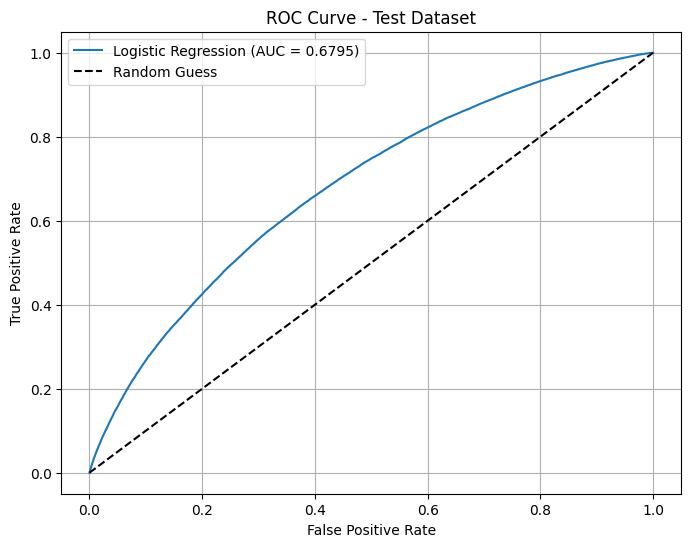

In [45]:
df_test = pd.read_csv('data/ready_test_dataset.csv')

df_test_binned = apply_bins(df_test, mapped_bins, mapped_fills)

df_test_binned['home_ownership'] = df_test_binned['home_ownership'].apply(home_owner)

df_test_binned = df_test_binned[list(COLS_TO_STAY)]

X_test = df_test_binned.drop('target', axis=1)
y_test = df_test_binned['target']

X_test_dummies = pd.get_dummies(X_test, drop_first=True)
print(X_test_dummies.columns)

X_test_dummies = X_test_dummies.reindex(columns=X_dummies.columns, fill_value=0)

y_test_pred_proba = lr_model.predict_proba(X_test_dummies)[:, 1]
y_test_pred = lr_model.predict(X_test_dummies)

auc_test = roc_auc_score(y_test, y_test_pred_proba)
gini_test = 2 * auc_test - 1

print("Wyniki dla zbioru testowego")
print(f"AUC: {auc_test:.4f}")
print(f"Gini: {gini_test:.4f}")
print()
print(classification_report(y_test, y_test_pred))

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_test:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
df_test_binned

,total_rev_hi_lim_bins,target,home_ownership,bc_util_bins,annual_inc_bins,dti_bins,loan_amnt_bins,inq_last_6mths_bins,tot_cur_bal_bins,mo_sin_old_rev_tl_op_bins,revol_util_bins,num_tl_op_past_12m_bins,probability_bins
0,9.2k-13.7k,1,MORTGAGE,0-33.8,65k-80k,12.1-15,15k-21k,0,225+,0-96,25.8-37.5,1-2,0.540+
1,56k+,0,MORTGAGE,0-33.8,105k+,12.1-15,7k-10.5k,1,225+,156-216,0-25.8,2-3,0-0.341
2,23.3k-29.9k,0,MORTGAGE,80.6-92.3,51k-65k,8.5-12.1,21k+,1,0-225k,216+,46.9-55.4,1-2,0.540+
3,39.2k-56k,0,RENT,0-33.8,0-40k,0-8.5,0-7k,0,0-225k,0-96,0-25.8,0-1,0-0.341
4,29.9k-39.2k,0,RENT,67.4-80.6,51k-65k,20.8-24.2,10.5k-15k,0,0-225k,216+,55.4-63.8,3+,0-0.341
...,...,...,...,...,...,...,...,...,...,...,...,...,...
269795,56k+,0,OWN_OTHER,67.4-80.6,105k+,17.8-20.8,15k-21k,1,0-225k,124-156,25.8-37.5,0-1,0-0.341
269796,56k+,1,MORTGAGE,0-33.8,105k+,8.5-12.1,21k+,0,225+,0-96,25.8-37.5,1-2,0.540+
269797,56k+,0,MORTGAGE,67.4-80.6,105k+,20.8-24.2,21k+,1,225+,156-216,83.6+,1-2,0.404-0.508
269798,13.7k-18.2k,0,RENT,67.4-80.6,105k+,12.1-15,15k-21k,0,0-225k,216+,46.9-55.4,1-2,0.540+


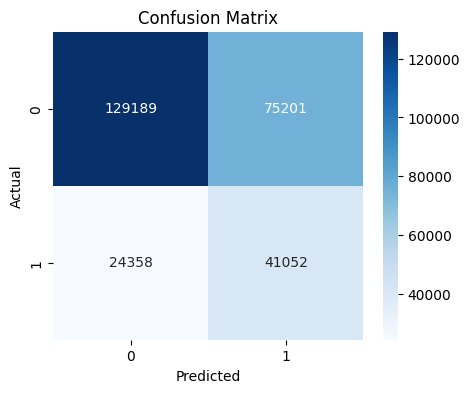

In [47]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Index(['total_rev_hi_lim_bins_13.7k-18.2k',
       'total_rev_hi_lim_bins_18.2k-23.3k',
       'total_rev_hi_lim_bins_23.3k-29.9k',
       'total_rev_hi_lim_bins_29.9k-39.2k', 'total_rev_hi_lim_bins_39.2k-56k',
       'total_rev_hi_lim_bins_56k+', 'total_rev_hi_lim_bins_9.2k-13.7k',
       'home_ownership_OWN_OTHER', 'home_ownership_RENT',
       'bc_util_bins_33.8-52.6', 'bc_util_bins_52.6-67.4',
       'bc_util_bins_67.4-80.6', 'bc_util_bins_80.6-92.3',
       'bc_util_bins_92.3+', 'annual_inc_bins_105k+',
       'annual_inc_bins_40k-51k', 'annual_inc_bins_51k-65k',
       'annual_inc_bins_65k-80k', 'annual_inc_bins_80k-105k',
       'dti_bins_12.1-15', 'dti_bins_15-17.8', 'dti_bins_17.8-20.8',
       'dti_bins_20.8-24.2', 'dti_bins_24.2-28.6', 'dti_bins_28.6+',
       'dti_bins_8.5-12.1', 'loan_amnt_bins_10.5k-15k',
       'loan_amnt_bins_15k-21k', 'loan_amnt_bins_21k+',
       'loan_amnt_bins_7k-10.5k', 'inq_last_6mths_bins_1',
       'inq_last_6mths_bins_2', 'inq_last_6mths_bins_3

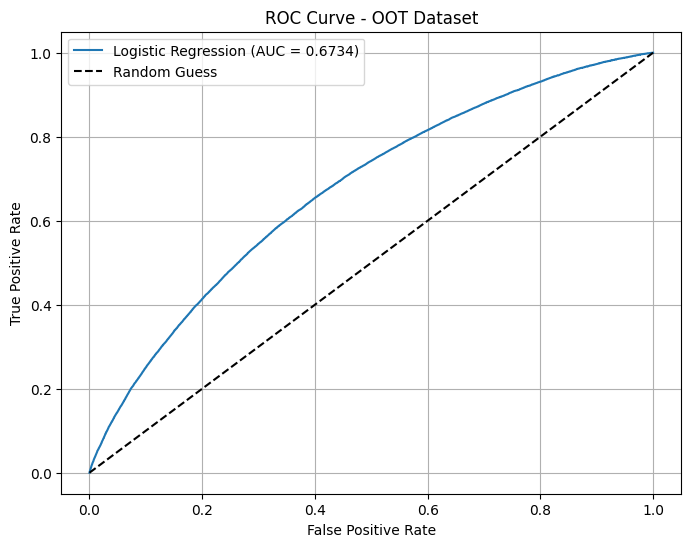

In [48]:
df_oot = pd.read_csv('data/ready_oot_dataset.csv')

df_oot_binned = apply_bins(df_oot, mapped_bins, mapped_fills)

df_oot_binned['home_ownership'] = df_oot_binned['home_ownership'].apply(home_owner)

df_oot_binned = df_oot_binned[list(COLS_TO_STAY)]

X_oot = df_oot_binned.drop('target', axis=1)
y_oot = df_oot_binned['target']

X_oot_dummies = pd.get_dummies(X_oot, drop_first=True)
print(X_oot_dummies.columns)

X_oot_dummies = X_oot_dummies.reindex(columns=X_dummies.columns, fill_value=0)

y_oot_pred_proba = lr_model.predict_proba(X_oot_dummies)[:, 1]
y_oot_pred = lr_model.predict(X_oot_dummies)

auc_oot = roc_auc_score(y_oot, y_oot_pred_proba)
gini_oot = 2 * auc_oot - 1

print("Wyniki dla zbioru OOT")
print(f"AUC: {auc_oot:.4f}")
print(f"Gini: {gini_oot:.4f}")
print()
print(classification_report(y_oot, y_oot_pred))

fpr, tpr, thresholds = roc_curve(y_oot, y_oot_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_oot:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - OOT Dataset')
plt.legend()
plt.grid(True)
plt.show()

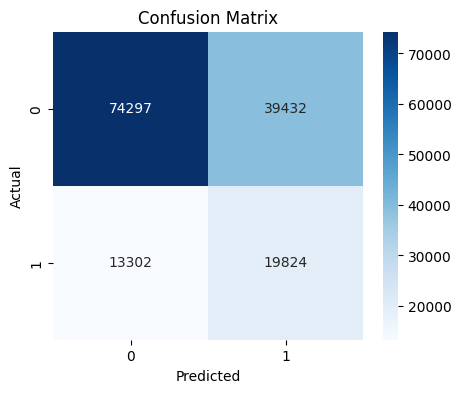

In [49]:
cm_oot = confusion_matrix(y_oot, y_oot_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_oot, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Change from dummies to WoE values

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
import joblib

In [8]:
mapped_bins = {
    "loan_amnt": {
        "bins": [-np.inf, 7000.0, 10500.0, 15000.0, 21000.0, np.inf],
        "labels": ["0-7k", "7k-10.5k", "10.5k-15k", "15k-21k", "21k+"]
    },
    "bc_util": {
        "bins": [-np.inf, 33.8, 52.6, 67.4, 80.6, 92.3, np.inf],
        "labels": ["0-33.8", "33.8-52.6", "52.6-67.4", "67.4-80.6", "80.6-92.3", "92.3+"]
    },
    "revol_util": {
        "bins": [-np.inf, 25.8, 37.5, 46.9, 55.4, 63.8, 72.8, 83.6, np.inf],
        "labels": ["0-25.8", "25.8-37.5", "37.5-46.9", "46.9-55.4", "55.4-63.8", "63.8-72.8", "72.8-83.6", "83.6+"]
    },
    "mo_sin_old_rev_tl_op": {
        "bins": [-np.inf, 96.0, 124.0, 156.0, 216.0, np.inf],
        "labels": ["0-96", "96-124", "124-156", "156-216", "216+"]
    },
    "num_tl_op_past_12m": {
        "bins": [-np.inf, 1.0, 2.0, 3.0, np.inf],
        "labels": ["0-1", "1-2", "2-3", "3+"]
    },
    "dti": {
        "bins": [-np.inf, 8.52, 12.06, 14.97, 17.8, 20.76, 24.2, 28.61, np.inf],
        "labels": ["0-8.5", "8.5-12.1", "12.1-15", "15-17.8", "17.8-20.8", "20.8-24.2", "24.2-28.6", "28.6+"]
    },
    "annual_inc": {
        "bins": [-np.inf, 40000.0, 51000.0, 65000.0, 80000.0, 105000.0, np.inf],
        "labels": ["0-40k", "40k-51k", "51k-65k", "65k-80k", "80k-105k", "105k+"]
    },
    "tot_cur_bal": {
        "bins": [-np.inf, 225000.0, np.inf],
        "labels": ["0-225k", "225+"]
    },
    "total_rev_hi_lim": {
        "bins": [-np.inf, 9200.0, 13700.0, 18200.0, 23300.0, 29900.0, 39232.5, 56000.0, np.inf],
        "labels": ["0-9.2k", "9.2k-13.7k", "13.7k-18.2k", "18.2k-23.3k", "23.3k-29.9k", "29.9k-39.2k", "39.2k-56k", "56k+"]
    },
    "inq_last_6mths": {
        "bins": [-np.inf, 0.001, 1, 3, np.inf],
        "labels": ["0", "1", "2", "3+"]
    },
    "probability": {
        "bins": [-np.inf, 0.341, 0.404, 0.508, 0.540, np.inf],
        "labels": ["0-0.341", "0.341-0.404", "0.404-0.508", "0.508-0.540", "0.540+"]
    },
    "home_ownership": {
        "bins": None,
        "labels": ["RENT", "MORTGAGE", "OWN_OTHER"]
    }
}


mapped_fills = {
    "revol_util": 55.4,
    "bc_util": 67.4,
    "total_rev_hi_lim": 0,
    "inq_last_6mths": 0,
    "annual_inc": 0,
    # "home_ownership": 0, function home_owner will take care of it
    "num_tl_op_past_12m": 0,
    "probability": 0,
    "bc_util": 0,
    "dti": 0,
    "target": 0,
    "loan_amnt": 0,
    "revol_util": 0,
    "tot_cur_bal": 0,
    "mo_sin_old_rev_tl_op": 0,
}

cols_to_read = list(mapped_bins.keys())
cols_to_read.extend(["target", "home_ownership"])


In [17]:
def calculate_woe(df, feature, target, bins=None, labels=None):
    df_temp = df[[feature, target]].copy()

    if bins is not None:
        df_temp[feature + "_bins"] = pd.cut(
            df_temp[feature],
            bins=bins,
            labels=labels,
            include_lowest=True,
        )
    else:
        df_temp[feature + "_bins"] = df_temp[feature]

    grouped = df_temp.groupby(feature + "_bins")[target].agg(
        ["count", "sum"]
    ).reset_index()

    grouped.columns = ["bin", "total", "events"]
    grouped["non_events"] = grouped["total"] - grouped["events"]

    total_events = grouped["events"].sum()
    total_non_events = grouped["non_events"].sum()

    grouped["event_rate"] = grouped["events"] / total_events
    grouped["non_event_rate"] = grouped["non_events"] / total_non_events

    grouped["event_rate"] = grouped["event_rate"].replace(0, 1e-6)
    grouped["non_event_rate"] = grouped["non_event_rate"].replace(0, 1e-6)

    grouped["WoE"] = np.log(
        grouped["event_rate"] / grouped["non_event_rate"]
    )

    woe_dict = dict(zip(grouped["bin"], grouped["WoE"]))

    return grouped, woe_dict



def apply_woe_transformation(df, mapped_bins, woe_maps):
    df_new = df.copy()

    for col, config in mapped_bins.items():
        required_cols = list(mapped_bins.keys())

        missing_cols = [
            col for col in required_cols
            if col not in df_new.columns
        ]

        if missing_cols:
            raise ValueError(
                f"Missing required columns: {missing_cols}"
            )

        bin_col = col + "_bins"

        if config["bins"] is not None:
            df_new[bin_col] = pd.cut(
                df_new[col],
                bins=config["bins"],
                labels=config["labels"],
                include_lowest=True,
            )

        else:
            allowed_labels = config["labels"]

            df_new[bin_col] = (
                df_new[col]
                .astype(str)
                .apply(home_owner)
            )

        df_new[bin_col] = df_new[bin_col].map(woe_maps[col]).astype(float).fillna(0.0)


    return df_new



def home_owner(val):
    if val in ["RENT", "MORTGAGE"]:
        return val
    return "OWN_OTHER"

In [18]:
df_train = pd.read_csv("data/ready_train_dataset.csv", usecols=cols_to_read)
df_test = pd.read_csv("data/ready_test_dataset.csv", usecols=cols_to_read)

df_train["home_ownership"] = df_train["home_ownership"].apply(home_owner)
df_test["home_ownership"] = df_test["home_ownership"].apply(home_owner)

for col, value in mapped_fills.items():
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna(value)
        df_test[col] = df_test[col].fillna(value)

In [19]:
woe_maps = {}
woe_tables = {}

for col, config in mapped_bins.items():
    table, woe_dict = calculate_woe(
        df_train,
        feature=col,
        target="target",
        bins=config["bins"],
        labels=config["labels"],
    )

    woe_tables[col] = table
    woe_maps[col] = woe_dict

C:\Users\User\AppData\Local\Temp\ipykernel_29432\936001816.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby(feature + "_bins")[target].agg(
C:\Users\User\AppData\Local\Temp\ipykernel_29432\936001816.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby(feature + "_bins")[target].agg(
C:\Users\User\AppData\Local\Temp\ipykernel_29432\936001816.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default 

In [12]:
woe_maps

{'loan_amnt': {'0-7k': -0.3096895566140675,
  '7k-10.5k': -0.14839396489719112,
  '10.5k-15k': 0.07317771133955554,
  '15k-21k': 0.16060278332058156,
  '21k+': 0.17602849687365563},
 'bc_util': {'0-33.8': -0.23579124561341921,
  '33.8-52.6': -0.13663951809007416,
  '52.6-67.4': -0.026369763568697156,
  '67.4-80.6': 0.03168179117677081,
  '80.6-92.3': 0.08826967992070858,
  '92.3+': 0.24881094746796417},
 'revol_util': {'0-25.8': -0.2824252604509185,
  '25.8-37.5': -0.1409502448649134,
  '37.5-46.9': -0.05808321322576112,
  '46.9-55.4': 0.015557561632685266,
  '55.4-63.8': 0.04599929351808013,
  '63.8-72.8': 0.09121901668652292,
  '72.8-83.6': 0.12872654443961756,
  '83.6+': 0.15432806990206338},
 'mo_sin_old_rev_tl_op': {'0-96': 0.23358477028086658,
  '96-124': 0.12032730093963011,
  '124-156': 0.036942364961302016,
  '156-216': -0.04709502544681096,
  '216+': -0.17260901611764895},
 'num_tl_op_past_12m': {'0-1': -0.2542927947281371,
  '1-2': -0.0007594862176777524,
  '2-3': 0.16380834

In [ ]:
df_train = apply_woe_transformation(
    df_train,
    mapped_bins,
    woe_maps,
)

df_test = apply_woe_transformation(
    df_test,
    mapped_bins,
    woe_maps,
)


woe_columns = [col + "_bins" for col in mapped_bins.keys()]

X_train = df_train[woe_columns]
X_test = df_test[woe_columns]

y_train = df_train["target"]
y_test = df_test["target"]

c_values = [1] # 0.001, 0.01, 0.1, 1.0, 10.0, 100.0 no difference beyond 0.1
best_auc = 0
best_model = None
best_c = None

print(f"{'C Value':<10} | {'Train AUC':<12} | {'Test AUC':<12} | {'Gini Test':<12}")
print("_" * 55)

for c in c_values:
    model = LogisticRegression(
        penalty='l2', 
        C=c, 
        solver='lbfgs', 
        max_iter=1000, 
        class_weight='balanced',
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]
    
    auc_train = roc_auc_score(y_train, train_proba)
    auc_test = roc_auc_score(y_test, test_proba)
    gini_test = 2 * auc_test - 1
    
    print(f"{c:<10} | {auc_train:<12.4f} | {auc_test:<12.4f} | {gini_test:<12.4f}")
    
    if auc_test > best_auc:
        best_auc = auc_test
        best_model = model
        best_c = c

print("_" * 55)
print(f"NAJLEPSZY MODEL: C = {best_c} z Test AUC = {best_auc:.4f}")

coefficients = pd.DataFrame({
    'Feature': ['Intercept'] + list(X_train.columns),
    'Coeff': [best_model.intercept_[0]] + list(best_model.coef_[0])
})

print(coefficients)

C Value    | Train AUC    | Test AUC     | Gini Test   
_______________________________________________________


c:\Uzytkowe\projekty\Risk\risk_pred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


0.001      | 0.6981       | 0.6822       | 0.3645      


c:\Uzytkowe\projekty\Risk\risk_pred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


0.01       | 0.6981       | 0.6829       | 0.3659      


...

1.0        | 0.6981       | 0.6830       | 0.3660      


c:\Uzytkowe\projekty\Risk\risk_pred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


10.0       | 0.6981       | 0.6830       | 0.3660      


c:\Uzytkowe\projekty\Risk\risk_pred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


100.0      | 0.6981       | 0.6830       | 0.3660      
_______________________________________________________
NAJLEPSZY MODEL: C = 100.0 z Test AUC = 0.6830
                      Feature     Coeff
0                   Intercept  0.000424
1              loan_amnt_bins  0.621297
2                bc_util_bins  0.677033
3             revol_util_bins  0.536480
4   mo_sin_old_rev_tl_op_bins  0.485221
5     num_tl_op_past_12m_bins  0.963210
6                    dti_bins  0.599451
7             annual_inc_bins  0.889766
8            tot_cur_bal_bins -0.002073
9       total_rev_hi_lim_bins  0.630394
10        inq_last_6mths_bins  0.443866
11           probability_bins  0.871648
12        home_ownership_bins  0.676708


In [31]:
best_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclas

In [22]:

model_artifacts = {
    "model": best_model,
    "feature_order": woe_columns,
    "mapped_bins": mapped_bins,
    "woe_maps": woe_maps,
    "mapped_fills": mapped_fills,
}

joblib.dump(
    model_artifacts,
    "models/logistic_regression_woe_v1.joblib",
)

['models/logistic_regression_woe_v1.joblib']

In [37]:
model_artifacts

{'model': LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2',
                    random_state=42),
 'feature_order': ['loan_amnt_bins',
  'bc_util_bins',
  'revol_util_bins',
  'mo_sin_old_rev_tl_op_bins',
  'num_tl_op_past_12m_bins',
  'dti_bins',
  'annual_inc_bins',
  'tot_cur_bal_bins',
  'total_rev_hi_lim_bins',
  'inq_last_6mths_bins',
  'probability_bins'],
 'mapped_bins': {'loan_amnt': {'bins': [-inf,
    7000.0,
    10500.0,
    15000.0,
    21000.0,
    inf],
   'labels': ['0-7k', '7k-10.5k', '10.5k-15k', '15k-21k', '21k+']},
  'bc_util': {'bins': [-inf, 33.8, 52.6, 67.4, 80.6, 92.3, inf],
   'labels': ['0-33.8',
    '33.8-52.6',
    '52.6-67.4',
    '67.4-80.6',
    '80.6-92.3',
    '92.3+']},
  'revol_util': {'bins': [-inf, 25.8, 37.5, 46.9, 55.4, 63.8, 72.8, 83.6, inf],
   'labels': ['0-25.8',
    '25.8-37.5',
    '37.5-46.9',
    '46.9-55.4',
    '55.4-63.8',
    '63.8-72.8',
    '72.8-83.6',
    '83.6+']},
  'mo_sin_old_rev_tl_op': {'bins': [-i